## Custom nonlinear circuit solver

Authorerd 10/17 

SPICE doesn't have a way to run repeated DC simulations sequentially, but for our our limited use-case, it's easy to implement something ourselves.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import numba
from scipy.sparse import csr_matrix, lil_matrix
import scipy.sparse.linalg as spla

from spice_net import *

In [2]:
from train_nets import init_model_xor

grid_size = 4
G = nx.grid_graph([grid_size, grid_size], periodic=False)
G = nx.convert_node_labels_to_integers(G, first_label=1, ordering='sorted')
G.add_node(0)

grid_graph = nx.Graph()
grid_graph.add_nodes_from(sorted(G.nodes(data=True)))
grid_graph.add_edges_from(G.edges(data=True))

for e in grid_graph.edges:
    # grid_graph[e[0]][e[1]]["weight"] = np.random.uniform(0, 5)  # random init
    grid_graph[e[0]][e[1]]['weight'] = 2.5

input_labels = ['V-', 'V+', 'V1', 'V2']
output_labels = ['O']
node_cfg = (np.array([[6, 0], [8, 0], [16, 0], [14, 0]]), np.array([[11, 1]]))

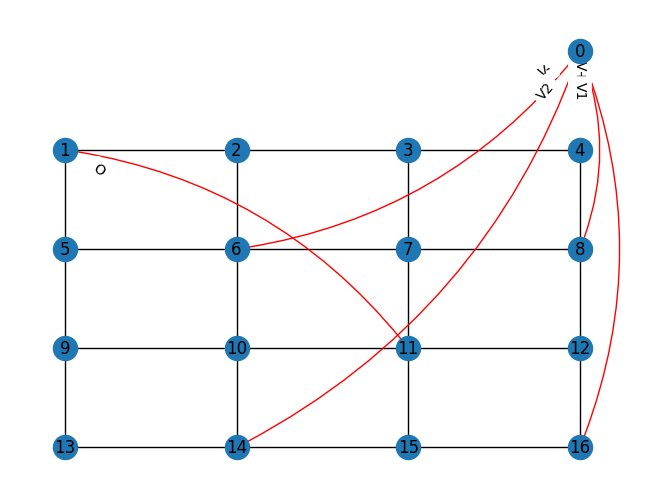

In [4]:
src_graph = nx.Graph()
src_graph.add_nodes_from(grid_graph.nodes)
for l, (u, v) in zip(input_labels + output_labels, np.concatenate(node_cfg, axis=0)):
    src_graph.add_edge(u, v, src=l)

pos = {i: ((i-1) % grid_size, -((i-1) // grid_size)) for i in grid_graph.nodes}
nx.draw(grid_graph, pos=pos, with_labels=True)
nx.draw_networkx_edges(src_graph, pos, edgelist=src_graph.edges(), edge_color='r',
                       connectionstyle="arc3,rad=-0.2", arrows=True, arrowstyle='-')
nx.draw_networkx_edge_labels(src_graph, pos, edge_labels={(u, v): d['src'] for u, v, d in src_graph.edges(data=True)}, label_pos=0.9)
plt.show()

In [7]:
xor_net = TransistorNetwork("??", grid_graph, node_cfg, solver='ngspice-subprocess')

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


In [9]:
print(xor_net)

.title ??
.subckt transistor_edge t_D t_S vgs=0.5
V1 t_G t_S {vgs}
R1 t_D t_S 1e+16
M1 t_D t_G t_S t_S Ideal
.ends transistor_edge
B1 6 0
B2 8 0
B3 16 0
B4 14 0
B5 11 1
Vindex index 0 1
X1 1 5 transistor_edge vg=2.5
X2 1 2 transistor_edge vg=2.5
X3 2 6 transistor_edge vg=2.5
X4 2 3 transistor_edge vg=2.5
X5 3 7 transistor_edge vg=2.5
X6 3 4 transistor_edge vg=2.5
X7 4 8 transistor_edge vg=2.5
X8 5 9 transistor_edge vg=2.5
X9 5 6 transistor_edge vg=2.5
X10 6 10 transistor_edge vg=2.5
X11 6 7 transistor_edge vg=2.5
X12 7 11 transistor_edge vg=2.5
X13 7 8 transistor_edge vg=2.5
X14 8 12 transistor_edge vg=2.5
X15 9 13 transistor_edge vg=2.5
X16 9 10 transistor_edge vg=2.5
X17 10 14 transistor_edge vg=2.5
X18 10 11 transistor_edge vg=2.5
X19 11 15 transistor_edge vg=2.5
X20 11 12 transistor_edge vg=2.5
X21 12 16 transistor_edge vg=2.5
X22 13 14 transistor_edge vg=2.5
X23 14 15 transistor_edge vg=2.5
X24 15 16 transistor_edge vg=2.5
.model Ideal NMOS (level=1)
.model NMOS NMOS (level=1)



In [21]:
%reload_ext autoreload
%autoreload 2

import PySpice.Spice.Xyce
import PySpice.Spice.Xyce.Server
from helpers import *
from spice_net import *

import numpy as np
import networkx as nx
import tqdm
import json
import matplotlib.pyplot as plt

from numba import jit
import numba

import cProfile

from scipy.sparse import csr_matrix, lil_matrix
import scipy.sparse.linalg as spla

import sksparse


In [22]:
# NMOS parameters
VTO = 0.0
KP = 2.0e-5
LIN_COEFF = 0.

# NMOS equations
@jit
def f(Vds, Vgs):
    if Vds >= 0: # forward active
        if Vgs - VTO < 0:
            return 0.
        if Vgs - VTO < Vds:
            return KP * (Vgs - VTO)**2 * (1 + LIN_COEFF * Vds)
        else:
            return KP * Vds * (2 * (Vgs - VTO) - Vds) * (1 + LIN_COEFF * Vds)
        
    else: # reverse active
        Vgd = Vgs - Vds
        if Vgd - VTO < 0:
            return 0.
        if Vgd - VTO < -Vds:
            return -KP * (Vgd - VTO)**2 * (1 - LIN_COEFF * Vds)
        else:
            return KP * Vds * (2 * (Vgd - VTO) + Vds) * (1 - LIN_COEFF * Vds)

@jit
def df(Vds, Vgs): # derivative wrt Vds 
    # TODO: should this be computed using autodiff?
    if Vds >= 0: # forward active
        if Vgs - VTO < 0:
            return 0.
        if Vgs - VTO < Vds:
            return KP * (Vgs - VTO)**2 * LIN_COEFF
        else:
            return -KP * (2 * (Vds - Vgs + VTO) + Vds * (3 * Vds - 4 * Vgs + 4 * VTO) * LIN_COEFF)
        
    else: # reverse active
        Vgd = Vgs - Vds
        if Vgd - VTO < 0:
            return 0.
        if Vgd - VTO < -Vds:
            return KP*LIN_COEFF*pow(-VTO - Vds + Vgs, 2) - KP*(-LIN_COEFF*Vds + 1)*(2*VTO + 2*Vds - 2*Vgs)
        else:
            return -KP*LIN_COEFF*Vds*(-2*VTO - Vds + 2*Vgs) - KP*Vds*(-LIN_COEFF*Vds + 1) + KP*(-LIN_COEFF*Vds + 1)*(-2*VTO - Vds + 2*Vgs)

# @jit 
# def op_newton(M, rhs, stamp_indices, params, operating_points):
def op_newton(data, sp_indices, rhs, stamp_indices, params, operating_points):
    # zero out things that will be overwritten
    for (n1, n2) in stamp_indices:
        # M[n1, n1] = 1e-12
        # M[n1, n2] = 0
        # M[n2, n1] = 0
        # M[n2, n2] = 1e-12
        data[sp_indices[(n1, n1)]] = 1e-16
        data[sp_indices[(n1, n2)]] = 0
        data[sp_indices[(n2, n1)]] = 0
        data[sp_indices[(n2, n2)]] = 1e-16
        
    op_guessses = np.zeros_like(params)
    for i, (n1, n2) in enumerate(stamp_indices):
        Vds = operating_points[n1] - operating_points[n2]
        Vgs = params[i]

        geq = df(Vds, Vgs)
        # geq = df(Vds, Vgs)
        if abs(geq) < 1e-12:
            geq = 1e-12 * np.sign(geq)
        op_guessses[i] = geq

        # stamp nodal matrix
        # M[n1, n1] += geq
        # M[n1, n2] -= geq
        # M[n2, n1] -= geq
        # M[n2, n2] += geq
        data[sp_indices[(n1, n1)]] += geq
        data[sp_indices[(n1, n2)]] -= geq
        data[sp_indices[(n2, n1)]] -= geq
        data[sp_indices[(n2, n2)]] += geq

        # stamp rhs

        rhs[n1] += (f(Vds, Vgs) - geq * Vds)
        rhs[n2] -= (f(Vds, Vgs) - geq * Vds)
    
    # return M, rhs, op_guessses
    return data, rhs

def set_voltages(rhs, n, vals):
    rhs *= 0
    for i, v in enumerate(vals):
        rhs[n + i] = v
    return rhs

def check_convergence(vprev, vcurr, icurr, iprev, stamp_indices, ABSTOL, RELTOL, VNTOL):
    v_conv = np.all(np.abs(vprev - vcurr) < VNTOL + RELTOL * np.maximum(np.abs(vcurr), np.abs(vprev)))
    # SPICE computes the current using nonlinear functions of the previous iteration's voltages
    # not sure how we could do that
    i_conv = np.all(np.abs(iprev - icurr) < ABSTOL + RELTOL * np.maximum(np.abs(icurr), np.abs(iprev)))

    return v_conv and i_conv

In [23]:
seed = 0
np.random.seed(seed)

grid_graph = nx.Graph()
grid_graph.add_node(0)
grid_graph.add_node(1)
grid_graph.add_node(2)
grid_graph.add_edge(0, 1)
grid_graph.add_edge(1, 2)

grid_graph = nx.convert_node_labels_to_integers(grid_graph, first_label=0, ordering='sorted')

node_cfg = (np.array([[2, 0]]), np.array([[1, 0]]))

In [24]:
grid_size = 4

seed = 0

np.random.seed(seed)

grid_graph = nx.grid_graph([grid_size, grid_size], periodic=False)
grid_graph = nx.convert_node_labels_to_integers(grid_graph, first_label=1, ordering='sorted')

grid_graph.add_node(0)

In [25]:
node_cfg = (np.array([[6, 0], [8, 0], [16, 0], [14, 0]]), np.array([[11, 1]]))

In [26]:
vgs_vals = np.ones_like(np.random.uniform(0.1, 0.9, grid_graph.number_of_edges())) * 0.5
for w, e in zip(vgs_vals,grid_graph.edges):
    grid_graph[e[0]][e[1]]['weight'] = w

# node_cfg = (np.array([[5, 16], [7, 16], [13, 16], [15, 16]]), np.array([[10, 0]]))
node_cfg = (np.array([[1, 0], [2, 0], [3,0], [4, 0]]), np.array([[4, 2]]))
free_sources = node_cfg[0]
clamp_sources = np.concatenate(node_cfg)

stamp_indices = np.array(list(grid_graph.edges))

n = grid_graph.number_of_nodes()
m = len(free_sources)

In [27]:
# CSR matrix stamped with source indices
m_csr = lil_matrix((n+m, n+m))
m_clamped = lil_matrix((n+m+1, n+m+1))
rhs = np.zeros(n+m, dtype=np.float64)

eps = 1e-12

for i in range(n-1):
    m_csr[i, i] = eps

# allocate nonzeros for nodal matrix
for n1, n2 in stamp_indices:
    m_csr[n1, n1] = eps
    m_csr[n2, n2] = eps
    m_csr[n1, n2] = 2
    m_csr[n2, n1] = 2

    m_clamped[n1, n1] = eps
    m_clamped[n2, n2] = eps
    m_clamped[n1, n2] = 2
    m_clamped[n2, n1] = 2

# stamp independent voltage sources
for i, (n1, n2) in enumerate(free_sources):
    m_csr[n1, n+i] = 1
    m_csr[n+i, n1] = 1
    m_csr[n2, n+i] = -1
    m_csr[n+i, n2] = -1

# # stamp clamped voltage sources
for i, (n1, n2) in enumerate(clamp_sources):
    m_clamped[n1, n+i] = 1
    m_clamped[n+i, n1] = 1
    m_clamped[n2, n+i] = -1
    m_clamped[n+i, n2] = -1

m_csr = m_csr.tocsr()
m_csr.data[m_csr.data == 2] = 0
M = m_csr

m_clamped = m_clamped.tocsr()
m_clamped.data[m_clamped.data == 2] = 0

# pre-compute sparse matrix indices
sp_indices = numba.typed.Dict.empty(
    key_type=numba.types.Tuple([numba.types.int64, numba.types.int64]),
    value_type=numba.types.int64
)
for i, (n1, n2) in enumerate(stamp_indices):
    sp_indices[(n1, n1)] = M.indptr[n1] + np.where(M.indices[M.indptr[n1]:M.indptr[n1+1]] == n1)[0][0]
    sp_indices[(n1, n2)] = M.indptr[n1] + np.where(M.indices[M.indptr[n1]:M.indptr[n1+1]] == n2)[0][0]
    sp_indices[(n2, n1)] = M.indptr[n2] + np.where(M.indices[M.indptr[n2]:M.indptr[n2+1]] == n1)[0][0]
    sp_indices[(n2, n2)] = M.indptr[n2] + np.where(M.indices[M.indptr[n2]:M.indptr[n2+1]] == n2)[0][0]

In [28]:
data = np.load("../data/xor_train_data_scale_1.0.npz")
inputs, outputs = data['inputs'], data['outputs']

In [29]:
nodal_guess = np.zeros(n + m, dtype=np.float32)

In [30]:
RELTOL = 1e-3
ABSTOL = 1e-6
VNTOL = 1e-6

In [31]:
def newton_loop(M, rhs, inputs, guess=None):
    # nodal_guess = np.zeros(n + m, dtype=np.float32)
    # prev = np.zeros_like(nodal_guess)

    # pre-compute sparse matrix indices 
    sp_indices = numba.typed.Dict.empty(key_type=numba.types.Tuple([numba.types.int64, numba.types.int64]), value_type=numba.types.int64)
    for n1, n2 in stamp_indices:
        sp_indices[(n1, n1)] = M.indptr[n1] + np.where(M.indices[M.indptr[n1]:M.indptr[n1+1]] == n1)[0][0]
        sp_indices[(n1, n2)] = M.indptr[n1] + np.where(M.indices[M.indptr[n1]:M.indptr[n1+1]] == n2)[0][0]
        sp_indices[(n2, n1)] = M.indptr[n2] + np.where(M.indices[M.indptr[n2]:M.indptr[n2+1]] == n1)[0][0]
        sp_indices[(n2, n2)] = M.indptr[n2] + np.where(M.indices[M.indptr[n2]:M.indptr[n2+1]] == n2)[0][0]

    # come up with initial solution for local linearization
    rhs = set_voltages(rhs, n, inputs)
    for n1, n2 in stamp_indices:
        M.data[sp_indices[(n1, n1)]] = 1e-16
        M.data[sp_indices[(n1, n2)]] = 0
        M.data[sp_indices[(n2, n1)]] = 0
        M.data[sp_indices[(n2, n2)]] = 1e-16
        
    for i, (n1, n2) in enumerate(stamp_indices):
        geq = df(guess[n1] - guess[n2], vgs_vals[i]) if guess is not None else 0.5
        M.data[sp_indices[(n1, n1)]] += geq
        M.data[sp_indices[(n1, n2)]] -= geq
        M.data[sp_indices[(n2, n1)]] -= geq
        M.data[sp_indices[(n2, n2)]] += geq
    for n1, n2 in stamp_indices:
        if n1 == 0:
            M.data[sp_indices[(n1, n2)]] = 0.
    M.data[sp_indices[(0, 0)]] = 1e16
    rhs[0] = 0.
    nodal_guess = spla.spsolve(M, rhs)

    MAX_ITERS = 100
    converged = False
    for it in range(MAX_ITERS):
        rhs = set_voltages(rhs, n, inputs)

        dd, rhs = op_newton(M.data, sp_indices, rhs, stamp_indices, vgs_vals, nodal_guess)
        M.data = dd
        # M[0] = 0
        for n1, n2 in stamp_indices:
            if n1 == 0:
                M.data[sp_indices[(n1, n1)]] = 0.
        M[0, 0] = 1e16
        rhs[0] = 0.

        prev = nodal_guess
        nodal_guess = spla.spsolve(M, rhs)
        # print(it, np.abs(prev - nodal_guess).max())

        converged = check_convergence(prev[:n], nodal_guess[:n], nodal_guess[n:], prev[n:], stamp_indices, ABSTOL, RELTOL, VNTOL)
        if converged:
            break
    return nodal_guess

In [33]:
print(M.toarray())

[[ 1.e-12  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00
   0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00 -1.e+00
  -1.e+00 -1.e+00 -1.e+00]
 [ 0.e+00  1.e-12  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00
   0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  1.e+00
   0.e+00  0.e+00  0.e+00]
 [ 0.e+00  0.e+00  1.e-12  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00
   0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00
   1.e+00  0.e+00  0.e+00]
 [ 0.e+00  0.e+00  0.e+00  1.e-12  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00
   0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00
   0.e+00  1.e+00  0.e+00]
 [ 0.e+00  0.e+00  0.e+00  0.e+00  1.e-12  0.e+00  0.e+00  0.e+00  0.e+00
   0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00
   0.e+00  0.e+00  1.e+00]
 [ 0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  1.e-12  0.e+00  0.e+00  0.e+00
   0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  0.e+00  

In [34]:
rhs

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0.])

In [35]:
net = LinearNetwork("hh", grid_graph, node_cfg, 'ngspice-subprocess')
# del net._models["Ideal"]
# net.model("Ideal", "NMOS", level=1, **{'vto': VTO, 'kp': KP, 'lambda': LIN_COEFF})
# del net._models["NMOS"]
# net.model("NMOS", "NMOS", level=1, **{'vto': VTO, 'kp': KP, 'lambda': LIN_COEFF})
net._prepare_simulation(data['inputs'][1])
res = net.cached_simulator.operating_point()

In [45]:
m, n

(4, 17)

In [46]:
res.nodes, res.branches

({'1': WaveForm 1 [0.11]@V,
  '2': WaveForm 2 [0.33]@V,
  '3': WaveForm 3 [0.]@V,
  '4': WaveForm 4 [0.45]@V,
  'index': WaveForm index [1.]@V,
  '5': WaveForm 5 [0.27996219]@V,
  '6': WaveForm 6 [0.25858443]@V,
  '7': WaveForm 7 [0.16081413]@V,
  '8': WaveForm 8 [0.36067706]@V,
  '9': WaveForm 9 [0.30126433]@V,
  '10': WaveForm 10 [0.26356138]@V,
  '11': WaveForm 11 [0.22385797]@V,
  '12': WaveForm 12 [0.33076687]@V,
  '13': WaveForm 13 [0.30085667]@V,
  '14': WaveForm 14 [0.27053882]@V,
  '15': WaveForm 15 [0.24719839]@V},
 {'B4': WaveForm B4 [-1.41872149]@A,
  'B3': WaveForm B3 [0.98162826]@A,
  'B2': WaveForm B2 [-1.24283115]@A,
  'B1': WaveForm B1 [0.55992438]@A,
  'Vindex': WaveForm Vindex [0.]@A})

In [56]:
n

17

In [55]:
theirs = np.array([0] + [res.nodes.get(str(i)).item() for i in range(1, n)] + [res.branches.get(f'B{i}').item() for i in range(1, m + 1)])

AttributeError: 'NoneType' object has no attribute 'item'

In [1070]:
theirs

array([ 0.  ,  0.11,  0.33,  0.  , -0.44, -1.32,  0.88,  0.  ])

In [1071]:
ours = newton_loop(M, rhs, data['inputs'][1])

In [1072]:
ours

array([-9.17193564e-15,  9.18293492e+01,  3.30000000e-01, -9.17193564e-15,
        4.50000000e-01, -1.32000000e-05, -4.50004934e-01, -9.17193492e+01])

In [1073]:
op_newton(M.data, sp_indices, rhs, stamp_indices, vgs_vals, rhs)

(array([ 9.74451386e-05, -7.74451386e-05, -2.00000000e-05, -1.00000000e+00,
        -1.00000000e+00, -1.00000000e+00, -1.00000000e+00, -7.74451386e-05,
         7.74451386e-05,  0.00000000e+00,  1.00000000e+00, -2.00000000e-05,
         2.00000000e-05,  0.00000000e+00,  1.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.00000000e-16,  1.00000000e+00, -1.00000000e+00,
         1.00000000e+00,  1.00000000e+00, -1.00000000e+00,  1.00000000e+00,
        -1.00000000e+00,  1.00000000e+00, -1.00000000e+00,  1.00000000e+00]),
 array([ 4.12492993e-05,  1.43609221e+00,  5.00000000e-06, -1.43614564e+00,
         1.10000000e-01,  3.30000000e-01,  0.00000000e+00,  4.50000000e-01]))

In [38]:
# theirs_transistor = theirs.copy()

In [39]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [10, 5]

plt.plot(theirs_transistor[:n], '.-', label='SPICE (MOSFET Simulation)', antialiased=True)
plt.plot(theirs[:n], '.-', label='SPICE', antialiased=True)
plt.plot(ours[:n], '.-', label='Custom Solver', antialiased=True)
plt.title(f"Node Voltages in {grid_size}x{grid_size} Grid Network, Linear Resistor")
plt.xlabel("Node number")
plt.ylabel("Voltage (V)")
plt.legend()

NameError: name 'theirs_transistor' is not defined

In [1076]:
np.allclose(theirs[:n], theirs_transistor[:n])

False

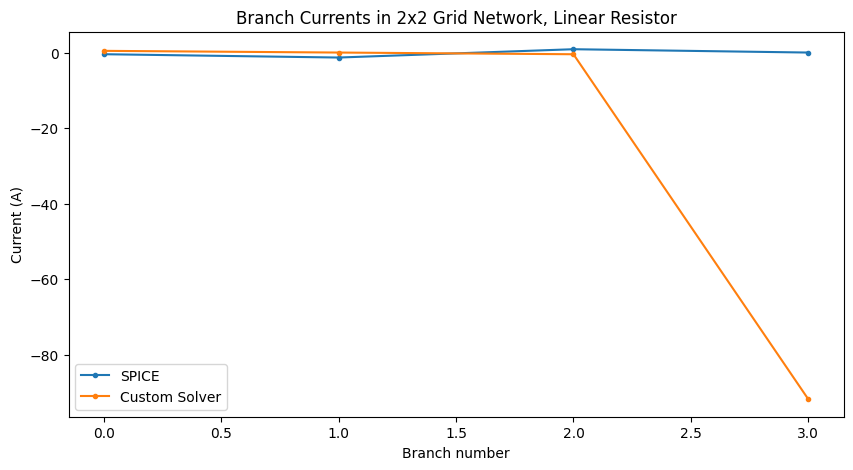

In [1077]:
plt.plot(theirs[n:], '.-', label='SPICE')
plt.plot(ours[n:], '.-', label='Custom Solver')
plt.title(f"Branch Currents in {grid_size}x{grid_size} Grid Network, Linear Resistor")
plt.xlabel("Branch number")
plt.ylabel("Current (A)")
plt.legend()

## Newton-Rhapson for DC operating point by hand

In [908]:
rhs = set_voltages(rhs, n, inputs[0])

In [909]:
rhs

array([ 0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  , -0.  ,
       -0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  , -0.  , -0.  ,
       -0.  , -0.  , -0.  ,  0.  ,  0.  , -0.  , -0.  , -0.  , -0.  ,
       -0.  , -0.  , -0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  , -0.  ,
       -0.  , -0.  , -0.  , -0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,
       -0.  , -0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  , -0.  ,
       -0.  , -0.  , -0.  ,  0.  ,  0.  ,  0.  ,  0.  , -0.  , -0.  ,
       -0.  , -0.  , -0.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  , -0.  ,
       -0.  , -0.  , -0.  , -0.  ,  0.  ,  0.  ,  0.  , -0.  ,  0.  ,
       -0.  ,  0.  ,  0.  ,  0.  , -0.  ,  0.  ,  0.  ,  0.  , -0.  ,
        0.  , -0.  , -0.  ,  0.  , -0.  ,  0.  , -0.  , -0.  , -0.  ,
       -0.  ,  0.11,  0.33,  0.  ,  0.  ])

In [910]:
M, rhs, op_guess = op_newton(M, rhs, stamp_indices, vgs_vals, nodal_guess)
M[0] = 0
M[0, 0] = eps
M.diagonal(), rhs, op_guess


TypeError: op_newton() missing 1 required positional argument: 'operating_points'

In [517]:
prev = nodal_guess
nodal_guess = spla.spsolve(M, rhs)

In [518]:
print(prev, nodal_guess)


[ 0.         -3.61801491 -0.08735373 -3.72491842 -3.66615884  0.10999907
 -3.77033607  0.18709163 -0.137835   -2.91251151 -0.26379524 -2.95152055
 -2.95152055 -0.14290837 -2.95152055 -0.14290837 -0.14290837  0.0260462
  0.09073413  0.0261271 ] [ 0.         -3.61801491 -0.08735373 -3.72491842 -3.66615884  0.10999907
 -3.77033607  0.18709163 -0.137835   -2.91251151 -0.26379524 -2.95152055
 -2.95152055 -0.14290837 -2.95152055 -0.14290837 -0.14290837  0.0260462
  0.09073413  0.0261271 ]


In [519]:
prev[:n] - nodal_guess[:n]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [520]:
conv = check_convergence(prev[:n], nodal_guess[:n], nodal_guess[n:], stamp_indices, ABSTOL, RELTOL, VNTOL)
conv

True

In [521]:
M @ nodal_guess - rhs

array([ 0.00000000e+00, -1.77635684e-15,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  8.88178420e-16,  0.00000000e+00,  1.77635684e-15,
        4.44089210e-16,  0.00000000e+00,  0.00000000e+00,  2.22044605e-16,
       -4.44089210e-16,  8.88178420e-16,  2.22044605e-16,  0.00000000e+00,
       -4.16333634e-17,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00])

## Informal experiments with real networks

In [1110]:
# redefine important quantities
vgs_vals
free_data = data["inputs"]
clamped_data = np.concatenate([data["inputs"], data["outputs"]], axis=1)

clamp_offset = free_data.shape[1]

free_sources = node_cfg[0]
clamp_sources = np.concatenate(node_cfg)

m_free = m_csr.copy()
m_clamped = m_clamped.copy()

In [1111]:
N_ITERS = 1000
NUDGE_FACTOR = 0.5
LEARNING_RATE = (1e-4)/(100 * 0.33 * 22e-6)

In [1113]:
for i in tqdm.trange(N_ITERS):
    # compute free node voltages
    free_guess = newton_loop(m_free, rhs, free_data[i % 4])

    nudges = clamped_data[i % 4].copy()
    nudges[:clamp_offset] *= NUDGE_FACTOR
    nudges[:clamp_offset] += (1-NUDGE_FACTOR) * (free_guess[node_cfg[1]][:, 0] - free_guess[node_cfg[1]][:, 1])
    clamped_guess = newton_loop(M, rhs, nudges, nudges)

    vfree = np.subtract(*free_guess[stamp_indices].T).T
    vclamped = np.subtract(*clamped_guess[stamp_indices].T).T
    vgs_vals -= LEARNING_RATE * (vfree**2 - vclamped**2)

  0%|          | 0/1000 [00:00<?, ?it/s]


KeyError: 

In [948]:
np.subtract(*free_guess[stamp_indices].T).T

array([ 8.85267466e-03, -4.06216048e-03,  1.26303778e-02, -1.58992439e-02,
        8.33197103e-03, -6.43627400e-03,  1.09482325e-02,  1.63438632e-02,
       -1.12184064e-02,  6.78002768e-03,  5.28011348e-02, -1.83025769e-02,
       -1.75621156e-02,  4.63268699e-02, -1.34805734e-02, -3.96367496e-02,
        1.10000000e-01,  2.39340546e-03, -7.31669954e-02,  1.83166995e-01,
        4.61612162e-02, -1.46833005e-01,  2.69011907e-01,  1.76067798e-01,
        1.97141347e-01,  4.82749533e-02,  9.14863695e-03,  3.37996360e-02,
        1.65587744e-02, -2.00968621e-03,  5.43086835e-03,  1.21096741e-02,
       -8.19314411e-03,  1.92289177e-03,  1.89601247e-02, -4.15283805e-03,
        4.32372992e-02, -3.09273592e-02, -2.40363804e-02, -7.99282162e-03,
        2.40363804e-02, -2.73054320e-02,  0.00000000e+00, -3.31156587e-02,
       -6.09880928e-02,  5.10942739e-03, -2.35956065e-02,  1.45847497e-02,
        2.08345715e-03,  9.69397798e-03,  9.41695494e-04,  8.60169756e-03,
       -3.93003447e-03, -